# CKG Reasoner v2 — C_Malaria_2190

Organized Colab workflow for the manuscript experiments. The diagnostic reasoner is fitted without outcome labels; ground truth is used only after partitioning for retrospective evaluation.

## 0. Reproducibility configuration

In [1]:
# Manuscript configuration
DISEASE = 'Malaria'
TARGET = 'Result'
BASELINE_K = 2
RANDOM_STATE = 42
K_RANGE = range(2, 11)
CLUSTER_VARIABLES = ["P_evidence", "r", "c", "Confidence_Score"]
BOOTSTRAP_N = 1000
WITHHOLD_FRACTIONS = [0.10, 0.25, 0.50]
SEEDS = list(range(20))

print("Disease:", DISEASE)
print("Target:", TARGET)
print("Baseline K:", BASELINE_K)
print("Baseline clustering variables:", CLUSTER_VARIABLES)

Disease: Malaria
Target: Result
Baseline K: 2
Baseline clustering variables: ['P_evidence', 'r', 'c', 'Confidence_Score']


## 1. Colab / package setup

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Mounted at /content/drive


In [3]:
import sys
import os
import importlib

# ============================================================
# CKG REASONER — COLAB SOURCE SETUP + VALIDATION
# ============================================================

PACKAGE_PATH = "/content/drive/MyDrive/CKG/ckg_reasoner_package_v2"
SRC_PATH = os.path.join(PACKAGE_PATH, "src")
CKG_PATH = os.path.join(SRC_PATH, "ckg_reasoner")
DATA_PATH = os.path.join(CKG_PATH, "data")

print("=" * 70)
print("CKG REASONER — COLAB SOURCE SETUP")
print("=" * 70)

print("PACKAGE_PATH :", PACKAGE_PATH)
print("SRC_PATH     :", SRC_PATH)
print("CKG_PATH     :", CKG_PATH)

# ------------------------------------------------------------
# 1. Validate package structure
# ------------------------------------------------------------

required_directories = {
    "Package directory": PACKAGE_PATH,
    "Source directory": SRC_PATH,
    "CKG package directory": CKG_PATH,
}

for label, path in required_directories.items():
    exists = os.path.isdir(path)
    print(f"{label:<24}: {'OK' if exists else 'MISSING'}")

    if not exists:
        raise FileNotFoundError(
            f"{label} not found:\n{path}"
        )


required_files = [
    "__init__.py",
    "model.py",
    "reasoning.py",
    "knowledge.py",
]

missing_files = [
    filename
    for filename in required_files
    if not os.path.isfile(os.path.join(CKG_PATH, filename))
]

if missing_files:
    raise FileNotFoundError(
        "Required CKG package files are missing:\n"
        + "\n".join(f"  - {name}" for name in missing_files)
    )

print("\nRequired core package files: OK")


# ------------------------------------------------------------
# 2. Remove previously added CKG package paths
# ------------------------------------------------------------

old_paths = [
    p for p in sys.path
    if "ckg_reasoner_package" in str(p)
]

if old_paths:
    print("\nRemoving previous CKG source paths:")
    for p in old_paths:
        print("  ", p)

sys.path = [
    p for p in sys.path
    if "ckg_reasoner_package" not in str(p)
]


# ------------------------------------------------------------
# 3. Force the selected source directory to highest priority
# ------------------------------------------------------------

sys.path.insert(0, SRC_PATH)

print("\nActive source path:")
print(" ", sys.path[0])


# ------------------------------------------------------------
# 4. Remove stale imported CKG modules
# ------------------------------------------------------------

removed_modules = []

for name in list(sys.modules):
    if name == "ckg_reasoner" or name.startswith("ckg_reasoner."):
        removed_modules.append(name)
        del sys.modules[name]

if removed_modules:
    print("\nRemoved cached CKG modules:")
    for name in sorted(removed_modules):
        print("  ", name)
else:
    print("\nNo cached CKG modules found.")

importlib.invalidate_caches()


# ------------------------------------------------------------
# 5. Display package contents before import
# ------------------------------------------------------------

print("\n=== PACKAGE CONTENTS ===")

package_files = sorted(os.listdir(CKG_PATH))

for filename in package_files[:30]:
    print("  ", filename)

if len(package_files) > 30:
    print(f"  ... and {len(package_files) - 30} more")


# ------------------------------------------------------------
# 6. Import CKG Reasoner
# ------------------------------------------------------------

import ckg_reasoner
from ckg_reasoner import CKGModel


# ------------------------------------------------------------
# 7. Verify imported package
# ------------------------------------------------------------

print("\n=== IMPORT CHECK ===")

print("Imported from:")
print(" ", ckg_reasoner.__file__)

print("\nPackage path:")
for p in ckg_reasoner.__path__:
    print(" ", p)

CKG_VERSION = getattr(
    ckg_reasoner,
    "__version__",
    "NO VERSION"
)

print("\nVersion:", CKG_VERSION)
print(
    "CKGModel available:",
    hasattr(ckg_reasoner, "CKGModel")
)
print("CKGModel:", CKGModel)


# ------------------------------------------------------------
# 8. Safety check:
#    ensure Colab did not import another installed CKG package
# ------------------------------------------------------------

imported_file = os.path.realpath(ckg_reasoner.__file__)
expected_root = os.path.realpath(SRC_PATH)

try:
    common_root = os.path.commonpath(
        [imported_file, expected_root]
    )
except ValueError:
    common_root = ""

if common_root != expected_root:
    raise RuntimeError(
        "\nWRONG CKG PACKAGE IMPORTED!\n\n"
        f"Expected package under:\n{expected_root}\n\n"
        f"But imported:\n{imported_file}"
    )

print("\nSource-path verification: PASSED")


# ------------------------------------------------------------
# 9. Check important modules
# ------------------------------------------------------------

important_modules = [
    "condition_logic.py",
    "units.py",
    "function_policy.py",
    "functions.py",
    "clinical_transformer.py",
    "mapping.py",
    "retrieval.py",
    "reporting.py",
]

print("\n=== MODULE CHECK ===")

missing_modules = []

for filename in important_modules:
    path = os.path.join(CKG_PATH, filename)
    exists = os.path.isfile(path)

    print(
        f"{filename:<30}"
        f"{'OK' if exists else 'MISSING'}"
    )

    if not exists:
        missing_modules.append(filename)


# ------------------------------------------------------------
# 10. Check bundled knowledge/data files
# ------------------------------------------------------------

print("\n=== DATA / KNOWLEDGE CHECK ===")
print("Data directory:", DATA_PATH)
print(
    "Data directory exists:",
    os.path.isdir(DATA_PATH)
)

yaml_files = []

if os.path.isdir(DATA_PATH):

    for root, dirs, files in os.walk(DATA_PATH):

        for filename in files:

            if filename.lower().endswith(
                (".yaml", ".yml")
            ):
                yaml_files.append(
                    os.path.join(root, filename)
                )

    yaml_files = sorted(yaml_files)

    print("YAML/YML files found:", len(yaml_files))

    for path in yaml_files:
        print(
            "  ",
            os.path.relpath(path, CKG_PATH)
        )

else:
    print("WARNING: bundled data directory not found.")


# ------------------------------------------------------------
# 11. Final diagnostic summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CKG REASONER SETUP COMPLETED")
print("=" * 70)

print("Source       :", SRC_PATH)
print("Imported from:", ckg_reasoner.__file__)
print("Version      :", CKG_VERSION)
print("CKGModel     : READY")

print(
    "Core files   :",
    "OK" if not missing_files else "MISSING"
)

print(
    "Extra modules:",
    "OK" if not missing_modules
    else f"{len(missing_modules)} MISSING"
)

print(
    "Knowledge YAML:",
    len(yaml_files)
)

print("=" * 70)

CKG REASONER — COLAB SOURCE SETUP
PACKAGE_PATH : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2
SRC_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src
CKG_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner
Package directory       : OK
Source directory        : OK
CKG package directory   : OK

Required core package files: OK

Active source path:
  /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src

No cached CKG modules found.

=== PACKAGE CONTENTS ===
   __init__.py
   clinical_transformer.py
   condition_logic.py
   confidence.py
   config.py
   data
   evaluation.py
   explanation.py
   function_policy.py
   functions.py
   gaussian.py
   graphview.py
   hard_assignment.py
   kmeans.py
   knowledge.py
   legacy_activation.py
   mahalanobis.py
   manual_audit.py
   mapping.py
   model.py
   reasoning.py
   reporting.py
   retrieval.py
   separation.py
   uncertainty.py
   units.py
   visualization.py

=== IMPORT CHECK ===
Imported fro

In [4]:
from ckg_reasoner import CKGModel, __version__

model = CKGModel()

print("Version:", __version__)
print(model.kb.audit())

Version: 2
{'knowledge_base_path': '/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner/data/diseases', 'disease_graph_count': 3, 'diseases': ['Dengue Fever', 'Influenza', 'Malaria'], 'yaml_file_count': 12}


In [5]:
import ckg_reasoner
from ckg_reasoner import (
    CKGModel,
    HardAssignment,
    KMeansPartition,
    GaussianPartition,
    MahalanobisPartition
)

print("CKG Reasoner version:", ckg_reasoner.__version__)

model = CKGModel()

print("CKGModel created successfully.")

CKG Reasoner version: 2
CKGModel created successfully.


## 2. Load cohort

In [6]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/CKG/KG2_Selected_4_Datasets/C3_M1_Malaria_Bangladesh_2190.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nColumns:")
for col in df.columns:
    print(col)

Shape: (2190, 13)


,Sex,Age,Hemoglobin(Hb%),Total WBC count(/cumm),Neutrophils,Lymphocytes,Total Cir.Eosinophils,HTC/PCV(%),MCH(pg),MCHC(g/dl),RDW-CV(%),Platelet Count,Result
0,Male,26,15.3,5800,43,41,245,48.5,30.10,31.67,15.22,195000,negative
1,Female,23,15.4,5500,44,42,343,44.5,31.04,32.13,14.00,160000,negative
2,Female,45,12.4,4800,43,42,310,41.0,27.90,29.13,12.30,92000,positive
3,Male,51,16.3,7000,41,43,232,50.1,31.30,32.70,13.50,194000,negative
4,Male,55,15.7,5000,45,42,267,49.0,30.00,32.78,15.60,230000,negative



Columns:
Sex
Age
Hemoglobin(Hb%)
Total WBC count(/cumm)
Neutrophils
Lymphocytes
Total Cir.Eosinophils
HTC/PCV(%)
MCH(pg)
MCHC(g/dl)
RDW-CV(%)
Platelet Count
Result


## 3. Map patient variables and run frozen KG reasoning

In [7]:
model.hmap(df, interactive=False)

print("\nDetected schema:")
print(model.detected_schema_)

print("\nDetected target:")
print(model.target_column_)

print("\nHeader mapping report:")
display(model.hmap_report())

Detected dataset schema: C3_M1_Malaria_2190 (confidence=1.00)
Successful matches found: 10 dataset headings mapped to ontology headings.
       dataset_heading     ontology_heading
       Hemoglobin(Hb%)  HGB_hemoglobin_g_dl
Total WBC count(/cumm)              LEU_wbc
           Neutrophils NEU_neutrophil_count
           Lymphocytes LYM_lymphocyte_count
 Total Cir.Eosinophils EOS_eosinophil_count
            HTC/PCV(%)       HCT_hematocrit
               MCH(pg)              MCH_mch
            MCHC(g/dl)            MCHC_mchc
             RDW-CV(%)              RDW_rdw
        Platelet Count   THR_platelet_count
Ignored metadata/target headings: ['id', 'Sex', 'Age', 'Result']

Detected schema:
C3_M1_Malaria_2190

Detected target:
Result

Header mapping report:


,dataset_heading,ontology_heading,status,confidence,source_unit,canonical_unit,unit_status
0,id,None,ignored,1.0,None,None,not_mapped
1,Sex,None,ignored,1.0,None,None,not_mapped
2,Age,None,ignored,1.0,None,None,not_mapped
3,Hemoglobin(Hb%),HGB_hemoglobin_g_dl,schema_exact,1.0,None,g/dL,unresolved
4,Total WBC count(/cumm),LEU_wbc,schema_exact,1.0,/uL,/uL,canonical
5,Neutrophils,NEU_neutrophil_count,schema_exact,1.0,None,%,unresolved
6,Lymphocytes,LYM_lymphocyte_count,schema_exact,1.0,None,%,unresolved
7,Total Cir.Eosinophils,EOS_eosinophil_count,schema_exact,1.0,None,%,unresolved
8,HTC/PCV(%),HCT_hematocrit,schema_exact,1.0,%,%,canonical
9,MCH(pg),MCH_mch,schema_exact,1.0,pg,pg,canonical


In [8]:
model.graphfit(strategy="exhaustive")



Graph fitting completed for 2190 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=3; target ordering=Malaria).


CKGModel(state='fitted', diseases=['Dengue Fever', 'Influenza', 'Malaria'], rows=2190)

## 4. Single-record reasoning sanity check

In [9]:
model.evidence("Malaria", row=0)
model.Continuous_reasoning("Malaria", row=0)
model.Deterministic_reasoning("Malaria", row=0)
model.Uncertainty("Malaria", row=0)
model.explain("Malaria", row=0)

{'Malaria': {'patient_id': 0,
  'disease': 'Malaria',
  'evidence_facts': [{'feature': 'THR_laboratory',
    'name': 'Thrombocytopenia',
    'observed': True,
    'observations': [{'component': 'platelet_count', 'value': 195000}],
    'similarity': 0.0,
    'clinical_importance': 0.7,
    'specificity': 0.7,
    'support': 0.8,
    'contradiction': 0.2,
    'positive_contribution': 0.0015887268996220617,
    'negative_contribution': 0.19779331727204005},
   {'feature': 'HGB_laboratory',
    'name': 'Anemia / Reduced Hemoglobin',
    'observed': True,
    'observations': [{'component': 'hemoglobin_g_dl', 'value': 15.3}],
    'similarity': 0.0,
    'clinical_importance': 0.5,
    'specificity': 0.5,
    'support': 0.5,
    'contradiction': 0.0,
    'positive_contribution': 0.0005066093429917289,
    'negative_contribution': 0.0},
   {'feature': 'LEU_laboratory',
    'name': 'White Blood Cell Count Change',
    'observed': True,
    'observations': [{'component': 'wbc', 'value': 5800}],
 

## 5. Label-free clustering diagnostics

Elbow-recommended cluster number: 2
Silhouette-recommended cluster number: 2
Combined best cluster number: 2


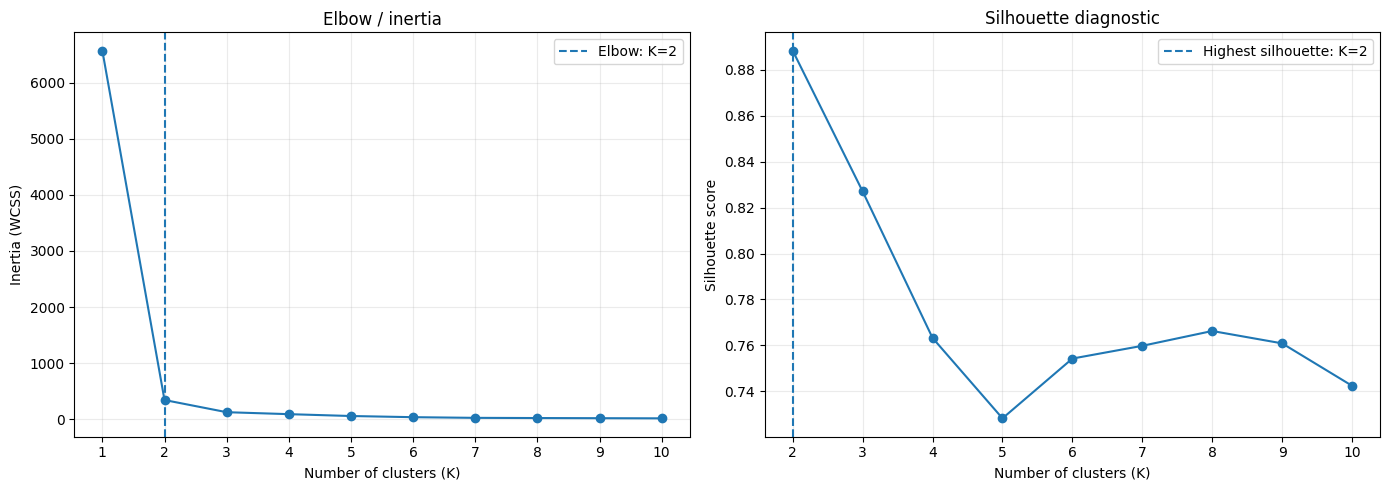

kmeans diagnostics complete. Advisory recommended n=2; choose n manually for the final fit.


,n,k,inertia,silhouette,elbow_strength,silhouette_strength,combined_score
0,1,1,6570.000000,NaN,0.000000,NaN,NaN
1,2,2,341.211745,0.888267,1.000000,1.000000,1.000000
2,3,3,124.251700,0.827022,0.907023,0.617217,0.762120
3,4,4,89.322271,0.763257,0.780951,0.218674,0.499812
4,5,5,56.146319,0.728269,0.654561,0.000000,0.327281
5,6,6,35.305721,0.754284,0.525928,0.162592,0.344260
6,7,7,23.346748,0.759834,0.395681,0.197281,0.296481
7,8,8,19.982004,0.766281,0.263871,0.237578,0.250724
8,9,9,17.261655,0.760900,0.131944,0.203945,0.167944
9,10,10,14.632124,0.742444,0.000000,0.088593,0.044297


Elbow k: 2
Silhouette k: 2
Combined best k: 2


In [10]:
# Baseline K-means diagnostics on all four post-KG coordinates.
kdiag = model.diagnostics(
    "kmeans", positive_disease=DISEASE, min_clusters=2, max_clusters=10,
    variables=None, show=True, print_recommendations=True
)
display(kdiag)
print("Elbow k:", kdiag.attrs.get("elbow_recommended_n"))
print("Silhouette k:", kdiag.attrs.get("silhouette_recommended_n"))
print("Combined best k:", kdiag.attrs.get("best_k", kdiag.attrs.get("recommended_n")))

## 6. Pre-specified baseline partition and retrospective evaluation

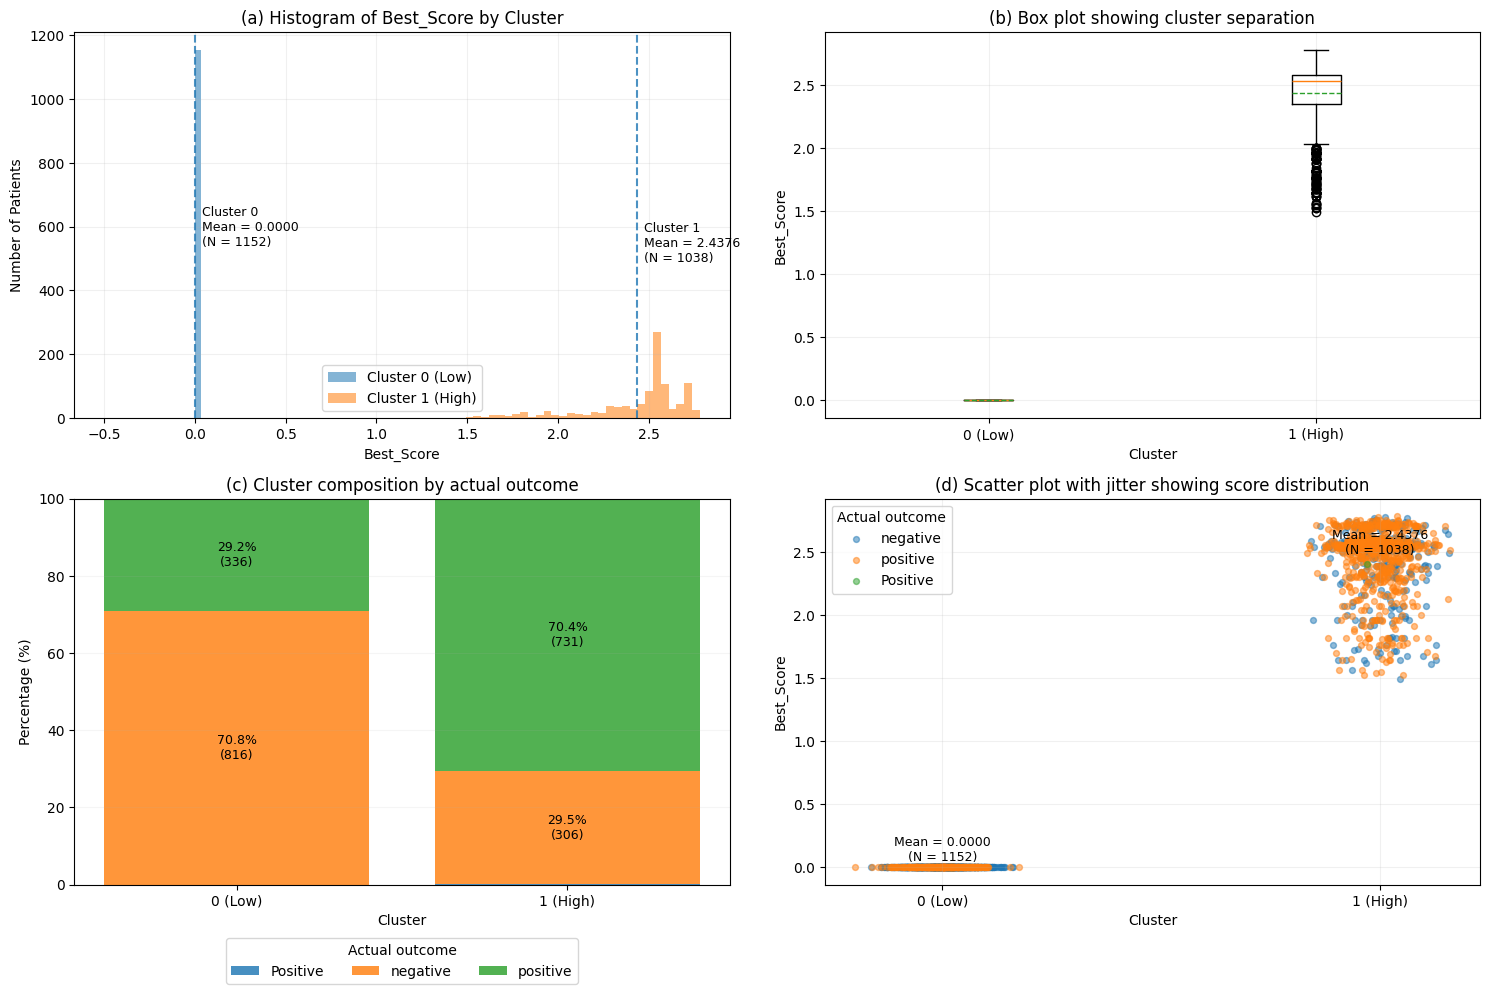

ALL-RECORD EVALUATION
{'n': 2190, 'accuracy': 0.7068493150684931, 'balanced_accuracy': np.float64(0.7063329928498467), 'precision_macro': 0.7067678227360308, 'recall_macro': 0.7063329928498467, 'f1_macro': 0.7064173977102737, 'f1_weighted': 0.7066950588691291, 'mcc': np.float64(0.4131005867348621), 'cohen_kappa': np.float64(0.41294512002645545), 'ground_truth_counts': {'negative': 1122, 'positive': 1068}, 'prediction_counts': {'negative': 1152, 'positive': 1038}, 'labels': ['negative', 'positive'], 'confusion_matrix': array([[816, 306],
       [336, 732]]), 'binary_label_order': ['negative', 'positive'], 'tn': 816, 'fp': 306, 'fn': 336, 'tp': 732, 'sensitivity': np.float64(0.6853932584269663), 'specificity': np.float64(0.7272727272727273), 'npv': np.float64(0.7083333333333334), 'ppv': np.float64(0.7052023121387283), 'f1_positive': 0.6951566951566952, 'f1': 0.6951566951566952, 'n_total': 2190, 'n_indeterminate': 0, 'coverage': 1.0, 'abstention_rate': 0.0, 'positive_disease': 'Malaria', 

In [11]:
from ckg_reasoner import KMeansPartition

km = model.partition(
    KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                    random_state=RANDOM_STATE, n_init=20, variables=None),
    DISEASE, show=False
)
km.visualize(y_true=model.df_[TARGET])

result_all = model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
result_selective = model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
print("ALL-RECORD EVALUATION")
print(result_all)
print("\nDECIDED/SUBSET EVALUATION")
print(result_selective)

## 7. Manuscript component ablation — post-KG representation

These experiments change only the coordinates supplied to K-means. They do **not** refit the diagnostic reasoner. The first six rows correspond to the manuscript table; `No CS` is an additional exploratory check.

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score

ABLATIONS = {
    "Full": None,  # variables=None => all four eligible coordinates
    "No P_evidence": ["r", "c", "Confidence_Score"],
    "No r": ["P_evidence", "c", "Confidence_Score"],
    "No c": ["P_evidence", "r", "Confidence_Score"],
    "P_evidence only": ["P_evidence"],
    "Profile only (r,c)": ["r", "c"],
    "No CS [exploratory]": ["P_evidence", "r", "c"],
}

def metric_value(d, *names):
    for n in names:
        if n in d: return d[n]
    return np.nan

baseline_tags = km.predictions_.astype(str)
rows=[]
partition_objects={}
for name, variables in ABLATIONS.items():
    part=model.partition(KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                         random_state=RANDOM_STATE, n_init=20, variables=variables), DISEASE, show=False)
    partition_objects[name]=part
    allm=model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    selm=model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    rows.append({
        "ablation":name, "variables":"ALL 4" if variables is None else ", ".join(variables),
        "ARI_vs_full":adjusted_rand_score(baseline_tags,part.predictions_.astype(str)),
        "accuracy_all":metric_value(allm,"accuracy"),
        "balanced_accuracy_all":metric_value(allm,"balanced_accuracy"),
        "MCC_all":metric_value(allm,"mcc","matthews_corrcoef"),
        "F1_positive_all":metric_value(allm,"f1_positive","f1"),
        "F1_positive_decided":metric_value(selm,"f1_positive","f1"),
        "coverage":metric_value(selm,"coverage"),
        "n_indeterminate":metric_value(selm,"n_indeterminate"),
    })
component_ablation=pd.DataFrame(rows)
display(component_ablation)

,ablation,variables,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,F1_positive_all,F1_positive_decided,coverage,n_indeterminate
0,Full,ALL 4,1.000000,0.706849,0.706333,0.413101,0.695157,0.695157,1.0,0
1,No P_evidence,"r, c, Confidence_Score",1.000000,0.706849,0.706333,0.413101,0.695157,0.695157,1.0,0
2,No r,"P_evidence, c, Confidence_Score",1.000000,0.706849,0.706333,0.413101,0.695157,0.695157,1.0,0
3,No c,"P_evidence, r, Confidence_Score",0.985435,0.705023,0.704415,0.409428,0.692088,0.692088,1.0,0
4,P_evidence only,P_evidence,1.000000,0.706849,0.706333,0.413101,0.695157,0.695157,1.0,0
5,"Profile only (r,c)","r, c",1.000000,0.706849,0.706333,0.413101,0.695157,0.695157,1.0,0
6,No CS [exploratory],"P_evidence, r, c",1.000000,0.706849,0.706333,0.413101,0.695157,0.695157,1.0,0


## 8. K sensitivity and 20-seed stability

In [13]:
# K sensitivity (K=2,...,10) using all four coordinates.
k_rows=[]
for kval in K_RANGE:
    p=model.partition(KMeansPartition(n_clusters=kval,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=model.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    k_rows.append({"k":kval,"accuracy":metric_value(a,"accuracy"),"balanced_accuracy":metric_value(a,"balanced_accuracy"),
                   "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
k_sensitivity=pd.DataFrame(k_rows)
display(k_sensitivity)

# Seed stability against seed-42 baseline.
seed_rows=[]
for seed in SEEDS:
    p=model.partition(KMeansPartition(n_clusters=BASELINE_K,min_clusters=2,max_clusters=10,random_state=seed,n_init=20,variables=None),DISEASE,show=False)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    seed_rows.append({"seed":seed,"ARI_vs_seed42":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
seed_stability=pd.DataFrame(seed_rows)
display(seed_stability)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

,k,accuracy,balanced_accuracy,f1_positive,coverage
0,2,0.706849,0.706333,0.695157,1.000000
1,3,0.657078,0.655303,0.682366,0.921918
2,4,0.610046,0.607082,0.662843,0.851598
3,5,0.510959,0.510380,0.709413,0.705479
4,6,0.346575,0.341840,0.525452,0.478539
5,7,0.345205,0.340436,0.520730,0.477169
6,8,0.339269,0.334350,0.503497,0.468950
7,9,0.339269,0.334350,0.503497,0.468950
8,10,0.164840,0.164118,0.651584,0.235160


,seed,ARI_vs_seed42,f1_positive,coverage
0,0,1.0,0.695157,1.0
1,1,1.0,0.695157,1.0
2,2,1.0,0.695157,1.0
3,3,1.0,0.695157,1.0
4,4,1.0,0.695157,1.0
5,5,1.0,0.695157,1.0
6,6,1.0,0.695157,1.0
7,7,1.0,0.695157,1.0
8,8,1.0,0.695157,1.0
9,9,1.0,0.695157,1.0


## 9. Bootstrap uncertainty (1,000 nonparametric resamples)

This bootstraps the fixed baseline predictions; it does not refit K-means and therefore quantifies sampling uncertainty of the reported retrospective metrics.

In [14]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef

truth=(model.df_[TARGET].astype(str).str.strip().str.lower().isin(["1","1.0","true","yes","positive","pos"])).astype(int).to_numpy()
pred_tag=km.predictions_.astype(str).to_numpy()
rng=np.random.default_rng(RANDOM_STATE)
boot=[]
for b in range(BOOTSTRAP_N):
    ix=rng.integers(0,len(truth),len(truth))
    yt=truth[ix]; pt=pred_tag[ix]
    yp=(pt=="positive").astype(int)
    decided=(pt!="indeterminate")
    row={"accuracy_all":accuracy_score(yt,yp),"coverage":decided.mean()}
    if len(np.unique(yt))>1:
        row["balanced_accuracy_all"]=balanced_accuracy_score(yt,yp)
        row["mcc_all"]=matthews_corrcoef(yt,yp)
    else:
        row["balanced_accuracy_all"]=np.nan; row["mcc_all"]=np.nan
    if decided.any(): row["f1_positive_decided"]=f1_score(yt[decided],yp[decided],zero_division=0)
    else: row["f1_positive_decided"]=np.nan
    boot.append(row)
bootstrap_df=pd.DataFrame(boot)
bootstrap_ci=bootstrap_df.quantile([0.025,0.5,0.975]).T.rename(columns={0.025:"CI_2.5%",0.5:"median",0.975:"CI_97.5%"})
display(bootstrap_ci)

,CI_2.5%,median,CI_97.5%
accuracy_all,0.687215,0.705936,0.725114
coverage,1.000000,1.000000,1.000000
balanced_accuracy_all,0.686267,0.705578,0.724804
mcc_all,0.373411,0.411691,0.450216
f1_positive_decided,0.672030,0.694845,0.716267


## 10. Reasoner-level ablations: contradiction and clinical importance

These rerun `graphfit()` after changing the encoded disease knowledge. They are intentionally separate from coordinate ablation.

In [15]:
from copy import deepcopy

def fresh_model_from_df(df_variant, knowledge_ablation=None):
    m=CKGModel()
    if knowledge_ablation is not None:
        for disease_key, refs in m.kb.reference_vectors.items():
            for _, ref in refs.items():
                if knowledge_ablation=="no_contradiction": ref["contradiction"]="None"
                elif knowledge_ablation=="importance_unity": ref["importance"]="Critical"  # encoded value 1.0
    m.hmap(df_variant.copy(),interactive=False)
    m.graphfit(strategy="exhaustive")
    return m

def run_model_partition(m, k=BASELINE_K):
    p=m.partition(KMeansPartition(n_clusters=k,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=m.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=m.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    return p,a,s

knowledge_rows=[]
for abl in ["no_contradiction","importance_unity"]:
    m2=fresh_model_from_df(df,abl)
    p,a,s=run_model_partition(m2)
    knowledge_rows.append({"ablation":abl,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
        "accuracy_all":metric_value(a,"accuracy"),"f1_positive_decided":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
knowledge_ablation=pd.DataFrame(knowledge_rows)
display(knowledge_ablation)

Detected dataset schema: C3_M1_Malaria_2190 (confidence=1.00)
Successful matches found: 10 dataset headings mapped to ontology headings.
       dataset_heading     ontology_heading
       Hemoglobin(Hb%)  HGB_hemoglobin_g_dl
Total WBC count(/cumm)              LEU_wbc
           Neutrophils NEU_neutrophil_count
           Lymphocytes LYM_lymphocyte_count
 Total Cir.Eosinophils EOS_eosinophil_count
            HTC/PCV(%)       HCT_hematocrit
               MCH(pg)              MCH_mch
            MCHC(g/dl)            MCHC_mchc
             RDW-CV(%)              RDW_rdw
        Platelet Count   THR_platelet_count
Ignored metadata/target headings: ['id', 'Sex', 'Age', 'Result']
Graph fitting completed for 2190 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=3; target ordering=Malaria).
Detected dataset schema: C3_M1_Malaria_2190 (confidence=1.00)
Successful matches found: 10 dataset heading

,ablation,ARI_vs_full,accuracy_all,f1_positive_decided,coverage
0,no_contradiction,1.0,0.706849,0.695157,1.0
1,importance_unity,1.0,0.706849,0.695157,1.0


## 11. Evidence-gate parameter sensitivity

One parameter family is varied at a time around the frozen baseline (α=0.05, β=10, γ=0.85). This is a controlled runtime patch for sensitivity analysis only; it does **not** modify the installed package files.

In [16]:
import math, contextlib
import ckg_reasoner.functions as ckg_functions
import ckg_reasoner.reasoning as ckg_reasoning

@contextlib.contextmanager
def temporary_gate(alpha=0.05,beta=10.0,gamma=0.85):
    old_fun=ckg_functions.manuscript_evidence_contributions
    old_reason=ckg_reasoning.manuscript_evidence_contributions
    def contrib(*,information_gate,diagnostic_role,importance,support,contradiction):
        def fgate(x):
            x=float(np.clip(x,0,1)); return 1.0/(1.0+alpha*math.exp(-beta*(x-gamma)))
        ig=float(np.clip(information_gate,0,1))
        return (fgate(ig)*max(float(diagnostic_role),0.0)*float(importance)*max(float(support),0.0),
                fgate(1.0-ig)*abs(float(contradiction)))
    ckg_functions.manuscript_evidence_contributions=contrib
    ckg_reasoning.manuscript_evidence_contributions=contrib
    try: yield
    finally:
        ckg_functions.manuscript_evidence_contributions=old_fun
        ckg_reasoning.manuscript_evidence_contributions=old_reason

gate_settings=[("baseline",0.05,10,0.85)]
gate_settings += [(f"alpha={x}",x,10,0.85) for x in [0.025,0.10]]
gate_settings += [(f"beta={x}",0.05,x,0.85) for x in [5,20]]
gate_settings += [(f"gamma={x}",0.05,10,x) for x in [0.75,0.95]]
gate_rows=[]
for name,a,b,g in gate_settings:
    with temporary_gate(a,b,g):
        mg=fresh_model_from_df(df)
        p,am,sm=run_model_partition(mg)
    gate_rows.append({"setting":name,"alpha":a,"beta":b,"gamma":g,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
gate_sensitivity=pd.DataFrame(gate_rows)
display(gate_sensitivity)

Detected dataset schema: C3_M1_Malaria_2190 (confidence=1.00)
Successful matches found: 10 dataset headings mapped to ontology headings.
       dataset_heading     ontology_heading
       Hemoglobin(Hb%)  HGB_hemoglobin_g_dl
Total WBC count(/cumm)              LEU_wbc
           Neutrophils NEU_neutrophil_count
           Lymphocytes LYM_lymphocyte_count
 Total Cir.Eosinophils EOS_eosinophil_count
            HTC/PCV(%)       HCT_hematocrit
               MCH(pg)              MCH_mch
            MCHC(g/dl)            MCHC_mchc
             RDW-CV(%)              RDW_rdw
        Platelet Count   THR_platelet_count
Ignored metadata/target headings: ['id', 'Sex', 'Age', 'Result']
Graph fitting completed for 2190 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=3; target ordering=Malaria).
Detected dataset schema: C3_M1_Malaria_2190 (confidence=1.00)
Successful matches found: 10 dataset heading

,setting,alpha,beta,gamma,ARI_vs_full,f1_positive_decided,coverage
0,baseline,0.050,10,0.85,1.0,0.695157,1.0
1,alpha=0.025,0.025,10,0.85,1.0,0.695157,1.0
2,alpha=0.1,0.100,10,0.85,1.0,0.695157,1.0
3,beta=5,0.050,5,0.85,1.0,0.695157,1.0
4,beta=20,0.050,20,0.85,1.0,0.695157,1.0
5,gamma=0.75,0.050,10,0.75,1.0,0.695157,1.0
6,gamma=0.95,0.050,10,0.95,1.0,0.695157,1.0


## 12. Controlled random evidence withholding

A fixed random seed masks 10%, 25%, and 50% of observed non-target patient fields and reruns the entire reasoner without refitting ontology weights. Adjust `PROTECTED_COLUMNS` if your local dataset contains additional administrative/non-evidence fields.

In [17]:
PROTECTED_COLUMNS={TARGET,"id","ID","Record_ID","record_id"}
evidence_cols=[c for c in df.columns if c not in PROTECTED_COLUMNS]
withhold_rows=[]
for frac in WITHHOLD_FRACTIONS:
    dfx=df.copy(); rng=np.random.default_rng(RANDOM_STATE+int(frac*100))
    vals=dfx[evidence_cols]
    observed=vals.notna().to_numpy(); draw=rng.random(observed.shape)<frac
    mask=observed & draw
    dfx.loc[:,evidence_cols]=vals.mask(mask)
    mw=fresh_model_from_df(dfx)
    p,am,sm=run_model_partition(mw)
    withhold_rows.append({"withheld_fraction":frac,"actually_masked":int(mask.sum()),"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                          "accuracy_all":metric_value(am,"accuracy"),"balanced_accuracy_all":metric_value(am,"balanced_accuracy"),
                          "MCC_all":metric_value(am,"mcc","matthews_corrcoef"),"f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
evidence_withholding=pd.DataFrame(withhold_rows)
display(evidence_withholding)

/tmp/ipykernel_3365/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[26. nan 45. ... 62. 43. 56.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3365/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[  nan   nan 4800. ...   nan 4215. 6852.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3365/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[43. 44. 43. ... 42. 42. 45.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3365/3971866365.py:9: Fut

Detected dataset schema: C3_M1_Malaria_2190 (confidence=1.00)
Successful matches found: 10 dataset headings mapped to ontology headings.
       dataset_heading     ontology_heading
       Hemoglobin(Hb%)  HGB_hemoglobin_g_dl
Total WBC count(/cumm)              LEU_wbc
           Neutrophils NEU_neutrophil_count
           Lymphocytes LYM_lymphocyte_count
 Total Cir.Eosinophils EOS_eosinophil_count
            HTC/PCV(%)       HCT_hematocrit
               MCH(pg)              MCH_mch
            MCHC(g/dl)            MCHC_mchc
             RDW-CV(%)              RDW_rdw
        Platelet Count   THR_platelet_count
Ignored metadata/target headings: ['id', 'Sex', 'Age', 'Result']
Graph fitting completed for 2190 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=3; target ordering=Malaria).


/tmp/ipykernel_3365/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan 23. 45. ... 62. 43. 56.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3365/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[5800. 5500.   nan ... 5987. 4215. 6852.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3365/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[43. 44. nan ... nan 42. 45.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3365/3971866365.py:9: Fut

Detected dataset schema: C3_M1_Malaria_2190 (confidence=1.00)
Successful matches found: 10 dataset headings mapped to ontology headings.
       dataset_heading     ontology_heading
       Hemoglobin(Hb%)  HGB_hemoglobin_g_dl
Total WBC count(/cumm)              LEU_wbc
           Neutrophils NEU_neutrophil_count
           Lymphocytes LYM_lymphocyte_count
 Total Cir.Eosinophils EOS_eosinophil_count
            HTC/PCV(%)       HCT_hematocrit
               MCH(pg)              MCH_mch
            MCHC(g/dl)            MCHC_mchc
             RDW-CV(%)              RDW_rdw
        Platelet Count   THR_platelet_count
Ignored metadata/target headings: ['id', 'Sex', 'Age', 'Result']
Graph fitting completed for 2190 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=3; target ordering=Malaria).


/tmp/ipykernel_3365/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan nan nan ... 62. 43. 56.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3365/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[  nan 5500. 4800. ... 5987.   nan 6852.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3365/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan nan 43. ... nan 42. 45.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3365/3971866365.py:9: Fut

Detected dataset schema: C3_M1_Malaria_2190 (confidence=1.00)
Successful matches found: 10 dataset headings mapped to ontology headings.
       dataset_heading     ontology_heading
       Hemoglobin(Hb%)  HGB_hemoglobin_g_dl
Total WBC count(/cumm)              LEU_wbc
           Neutrophils NEU_neutrophil_count
           Lymphocytes LYM_lymphocyte_count
 Total Cir.Eosinophils EOS_eosinophil_count
            HTC/PCV(%)       HCT_hematocrit
               MCH(pg)              MCH_mch
            MCHC(g/dl)            MCHC_mchc
             RDW-CV(%)              RDW_rdw
        Platelet Count   THR_platelet_count
Ignored metadata/target headings: ['id', 'Sex', 'Age', 'Result']
Graph fitting completed for 2190 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=3; target ordering=Malaria).


,withheld_fraction,actually_masked,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,f1_positive_decided,coverage
0,0.10,2620,0.817322,0.679909,0.678193,0.360242,0.649675,1.0
1,0.25,6646,0.565988,0.652511,0.648909,0.312056,0.585286,1.0
2,0.50,13295,0.267320,0.601826,0.595298,0.225401,0.447402,1.0


## 13. Export manuscript experiment tables

In [18]:
from pathlib import Path
RESULT_DIR=Path("/content/drive/MyDrive/CKG/Results")
RESULT_DIR.mkdir(parents=True,exist_ok=True)
OUT=RESULT_DIR/'C_Malaria_2190'
OUT.mkdir(parents=True,exist_ok=True)
component_ablation.to_csv(OUT/"component_ablation.csv",index=False)
k_sensitivity.to_csv(OUT/"k_sensitivity.csv",index=False)
seed_stability.to_csv(OUT/"seed_stability.csv",index=False)
bootstrap_ci.to_csv(OUT/"bootstrap_95CI.csv")
knowledge_ablation.to_csv(OUT/"knowledge_ablation.csv",index=False)
gate_sensitivity.to_csv(OUT/"gate_sensitivity.csv",index=False)
evidence_withholding.to_csv(OUT/"evidence_withholding.csv",index=False)
print("Saved manuscript experiment tables to:",OUT)

Saved manuscript experiment tables to: /content/drive/MyDrive/CKG/Results/C_Malaria_2190


## 14. Original explainability / FOL / output cells (preserved)

In [19]:
# ------------------------------------------------------------
# 2. Run both FOL outputs for every record
# ------------------------------------------------------------

for idx in range(len(model.df_)):

    model.explain(
        "Malaria",
        row=idx,
        format="fol"
    )

    model.explainable_layer(
        "Malaria",
        row=idx,
        format="report"
    )

print("FOL and explanation layers completed.")

FOL and explanation layers completed.


In [20]:
result_all = model.evaluate(
    y_true="Result",
    positive_disease="Malaria",
    positive_label=1,
    method=km
)

In [21]:
result_selective = model.evaluate_tag(
    y_true="Result",
    positive_disease="Malaria",
    positive_label=1,
    method=km
)

In [22]:
!pip install -q XlsxWriter
output_path = "/content/drive/MyDrive/CKG/Results/CKG_KMeans_Malaria_outputFOL_2190.xlsx"
model.output(
    output_path,
    #"CKG_output.xlsx",
    positive_disease="Malaria",
    method=km
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.4 MB/s eta 0:00:00
Output written: /content/drive/MyDrive/CKG/Results/CKG_KMeans_Malaria_outputFOL_2190.xlsx (method=kmeans); mismatch rows are yellow when actual outcome is available.


PosixPath('/content/drive/MyDrive/CKG/Results/CKG_KMeans_Malaria_outputFOL_2190.xlsx')

In [23]:
# ============================================================
# K-MEANS EVALUATION
# ============================================================

result_all = model.evaluate(
    y_true="Result",
    positive_disease="Malaria",
    positive_label=1,
    method=km
)

result_selective = model.evaluate_tag(
    y_true="Result",
    positive_disease="Malaria",
    positive_label=1,
    method=km
)

print("\n" + "=" * 70)
print("ALL-RECORD EVALUATION")
print("=" * 70)

for metric, value in result_all.items():
    print(f"{metric}: {value}")

print("\n" + "=" * 70)
print("SELECTIVE EVALUATION")
print("=" * 70)

for metric, value in result_selective.items():
    print(f"{metric}: {value}")


ALL-RECORD EVALUATION
n: 2190
accuracy: 0.7068493150684931
balanced_accuracy: 0.7063329928498467
precision_macro: 0.7067678227360308
recall_macro: 0.7063329928498467
f1_macro: 0.7064173977102737
f1_weighted: 0.7066950588691291
mcc: 0.4131005867348621
cohen_kappa: 0.41294512002645545
ground_truth_counts: {'negative': 1122, 'positive': 1068}
prediction_counts: {'negative': 1152, 'positive': 1038}
labels: ['negative', 'positive']
confusion_matrix: [[816 306]
 [336 732]]
binary_label_order: ['negative', 'positive']
tn: 816
fp: 306
fn: 336
tp: 732
sensitivity: 0.6853932584269663
specificity: 0.7272727272727273
npv: 0.7083333333333334
ppv: 0.7052023121387283
f1_positive: 0.6951566951566952
f1: 0.6951566951566952
n_total: 2190
n_indeterminate: 0
coverage: 1.0
abstention_rate: 0.0
positive_disease: Malaria
tag_method: kmeans
evaluation_mode: all records; indeterminate retained as a third predicted label

SELECTIVE EVALUATION
n: 2190
accuracy: 0.7068493150684931
balanced_accuracy: 0.7063329928

In [24]:
record_id = 3

idx = model.df_.index[model.df_["id"] == record_id][0]

print("Record ID:", record_id)
print("Row:", idx)

# Score / evidence
print("\n=== SCORE ===")
print(model.evidence("Malaria", row=idx))

# FOL
print("\n=== FOL ===")
print(model.explain("Malaria", row=idx, format="fol"))

Record ID: 3
Row: 2

=== SCORE ===
{'Malaria':               feature                                               name  \
0      THR_laboratory                                   Thrombocytopenia   
1      HGB_laboratory                        Anemia / Reduced Hemoglobin   
2      LEU_laboratory                      White Blood Cell Count Change   
3      NEU_laboratory                                   Neutrophil Count   
4      LYM_laboratory                                   Lymphocyte Count   
5      EOS_laboratory                                   Eosinophil Count   
6      HCT_laboratory                    Hematocrit / Packed Cell Volume   
7      MCH_laboratory                        Mean Corpuscular Hemoglobin   
8     MCHC_laboratory          Mean Corpuscular Hemoglobin Concentration   
9      RDW_laboratory                        Red Cell Distribution Width   
10     BSM_laboratory                Malaria Blood Smear / Film Positive   
11     RDT_laboratory             Malaria

In [25]:
record_id = 3
disease = "Malaria"

idx = model.df_.index[model.df_["id"] == record_id][0]

print("Record ID:", record_id, "| Row:", idx)

print("\n=== EVIDENCE / DISEASE SCORE / SIMILARITY ===")
print(model.evidence(disease, row=idx))

print("\n=== CONTINUOUS REASONING ===")
print(model.Continuous_reasoning(disease, row=idx))

print("\n=== DETERMINISTIC REASONING ===")
print(model.Deterministic_reasoning(disease, row=idx))

print("\n=== UNCERTAINTY ===")
print(model.Uncertainty(disease, row=idx))

print("\n=== FOL ===")
print(model.explain(disease, row=idx, format="fol"))

Record ID: 3 | Row: 2

=== EVIDENCE / DISEASE SCORE / SIMILARITY ===
{'Malaria':               feature                                               name  \
0      THR_laboratory                                   Thrombocytopenia   
1      HGB_laboratory                        Anemia / Reduced Hemoglobin   
2      LEU_laboratory                      White Blood Cell Count Change   
3      NEU_laboratory                                   Neutrophil Count   
4      LYM_laboratory                                   Lymphocyte Count   
5      EOS_laboratory                                   Eosinophil Count   
6      HCT_laboratory                    Hematocrit / Packed Cell Volume   
7      MCH_laboratory                        Mean Corpuscular Hemoglobin   
8     MCHC_laboratory          Mean Corpuscular Hemoglobin Concentration   
9      RDW_laboratory                        Red Cell Distribution Width   
10     BSM_laboratory                Malaria Blood Smear / Film Positive   
11     

In [26]:
scores = model.disease_scores()
print(scores)
row_scores = scores.iloc[0].sort_values(ascending=False)
print(row_scores)

for rank, (disease, score) in enumerate(row_scores.items(), start=1):
    print(f"Rank {rank}: {disease} = {score:.6f}")

        Dengue Fever  Influenza   Malaria
row_id                                   
0           0.384900   0.004098  0.000000
1           0.384900   0.004098  0.000000
2           0.606549   0.004098  0.900067
3           0.384900   0.004098  0.000000
4           0.384900   0.004098  0.000000
...              ...        ...       ...
2185        0.629866   0.004098  0.000000
2186        0.384900   0.004098  0.000000
2187        0.384900   0.004098  0.000000
2188        0.688639   0.350654  0.000000
2189        0.384900   0.004098  0.000000

[2190 rows x 3 columns]
Dengue Fever    0.384900
Influenza       0.004098
Malaria         0.000000
Name: 0, dtype: float64
Rank 1: Dengue Fever = 0.384900
Rank 2: Influenza = 0.004098
Rank 3: Malaria = 0.000000


In [27]:
# ============================================================
# DISEASE RANK CHECK — ROW 3
# ============================================================

ROW = 2

print("=" * 70)
print(f"DISEASE RANK DIAGNOSTIC — ROW {ROW}")
print("=" * 70)


# ------------------------------------------------------------
# 1. Malaria evidence
# ------------------------------------------------------------

print("\n--- MALARIA EVIDENCE ---")

malaria_evidence = model.evidance(
    "Malaria",
    ["specificity", "similarity"],
    row=ROW
)

display(malaria_evidence)


# ------------------------------------------------------------
# 2. Malaria continuous reasoning
# ------------------------------------------------------------

print("\n--- MALARIA CONTINUOUS REASONING ---")

malaria_cont = model.Continuous_reasoning(
    "Malaria",
    row=ROW
)

if malaria_cont is not None:
    display(malaria_cont)


# ------------------------------------------------------------
# 3. Malaria deterministic reasoning
# ------------------------------------------------------------

print("\n--- MALARIA DETERMINISTIC REASONING ---")

malaria_det = model.Deterministic_reasoning(
    "Malaria",
    row=ROW
)

if malaria_det is not None:
    display(malaria_det)


# ------------------------------------------------------------
# 4. Get scores for all diseases
# ------------------------------------------------------------

print("\n--- ALL DISEASE SCORES ---")

scores = model.disease_scores()

print("Score table shape:", scores.shape)

row_scores = scores.iloc[ROW]

display(
    row_scores.rename("Disease_Score").to_frame()
)


# ------------------------------------------------------------
# 5. Rank diseases
# ------------------------------------------------------------

ranked = row_scores.sort_values(
    ascending=False
)

print("\n--- DISEASE RANKING ---")

for rank, (disease, score) in enumerate(
    ranked.items(),
    start=1
):
    print(
        f"Rank {rank}: "
        f"{disease:<20} "
        f"{float(score):.6f}"
    )


# ------------------------------------------------------------
# 6. Check for zero-score / tied diseases
# ------------------------------------------------------------

print("\n--- SCORE DIAGNOSTICS ---")

zero_scores = row_scores[
    row_scores.abs() < 1e-12
]

if len(zero_scores):
    print(
        "Diseases with effectively zero score:",
        list(zero_scores.index)
    )
else:
    print("No disease has an exact zero score.")

if row_scores.nunique() < len(row_scores):
    print("WARNING: tied disease scores detected.")
else:
    print("No exact score ties detected.")

DISEASE RANK DIAGNOSTIC — ROW 2

--- MALARIA EVIDENCE ---


{'Malaria':               feature                                               name  \
 0      THR_laboratory                                   Thrombocytopenia   
 1      HGB_laboratory                        Anemia / Reduced Hemoglobin   
 2      LEU_laboratory                      White Blood Cell Count Change   
 3      NEU_laboratory                                   Neutrophil Count   
 4      LYM_laboratory                                   Lymphocyte Count   
 5      EOS_laboratory                                   Eosinophil Count   
 6      HCT_laboratory                    Hematocrit / Packed Cell Volume   
 7      MCH_laboratory                        Mean Corpuscular Hemoglobin   
 8     MCHC_laboratory          Mean Corpuscular Hemoglobin Concentration   
 9      RDW_laboratory                        Red Cell Distribution Width   
 10     BSM_laboratory                Malaria Blood Smear / Film Positive   
 11     RDT_laboratory             Malaria Rapid Diagnostic Test 


--- MALARIA CONTINUOUS REASONING ---


{'Malaria': {'evidence_accumulation': {'positive': 0.49739642519886607,
   'negative': 0.0008990926932321685,
   'net': 0.4964973325056339,
   'evidence_probability': 0.7211299284623163},
  'diagnostic_support': {'cosine_similarity': 1.0,
   'magnitude_ratio': 0.9790719866680083,
   'logistic_similarity': nan,
   'score': 0.9000673050434416}}}


--- MALARIA DETERMINISTIC REASONING ---


{'Malaria': {'pathognomonic_rules': False,
  'exclusionary_rules': False,
  'responsible_features': []}}


--- ALL DISEASE SCORES ---
Score table shape: (2190, 3)


,Disease_Score
Dengue Fever,0.606549
Influenza,0.004098
Malaria,0.900067



--- DISEASE RANKING ---
Rank 1: Malaria              0.900067
Rank 2: Dengue Fever         0.606549
Rank 3: Influenza            0.004098

--- SCORE DIAGNOSTICS ---
No disease has an exact zero score.
No exact score ties detected.
